In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch

import re
import pandas as pd
import numpy as np
import nltk
import pymorphy3
import optuna
import mlflow
import pickle
import implicit

from implicit.als import AlternatingLeastSquares
from scipy.sparse import coo_matrix, csr_matrix
from optuna.integration.mlflow import MLflowCallback
from mlflow.utils.mlflow_tags import MLFLOW_PARENT_RUN_ID
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from nltk.corpus import stopwords
from mlxtend.plotting import plot_decision_regions
from tqdm import tqdm
from scipy.sparse import csr_matrix, vstack
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from gensim.utils import simple_preprocess
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.simplefilter('ignore', FutureWarning)

from sklearn import set_config
set_config(display='diagram')

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "hr-ai-scout"

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

# Load data

In [4]:
df = pd.read_csv("total_df_10%.csv")
df.head()

,vacancy_id,vacancy_name,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,vacancy_salary_from,vacancy_salary_to,vacancy_salary_currency,vacancy_salary_gross,...,resume_education,resume_courses,resume_salary,resume_age,resume_total_experience,resume_experience_months,resume_location,resume_gender,resume_applicant_status,target
0,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Казанский Авиационный Институт'],NaN,NaN,65.0,19 лет,228.0,Москва,Мужчина,Рассматривает предложения,1
1,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,"['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...","['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...",NaN,43.0,17 лет 4 месяца,208.0,Москва,Мужчина,Рассматривает предложения,1
2,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Орский государственный педагогический инстит...,NaN,200 000 ₽ на руки,52.0,30 лет,360.0,Москва,Женщина,NaN,1
3,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Красноярский государственный университет'],NaN,500 000 ₽ на руки,56.0,29 лет 8 месяцев,356.0,Красноярск,Мужчина,Рассматривает предложения,1
4,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Белоруский Гос. Университет Информатики и Ра...,"['SAP CIS, SAP XI', 'Школа Логистики МАДИ', 'S...",NaN,48.0,25 лет 1 месяц,301.0,Moscow,Male,NaN,1


# Preprocessing

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
В первую очередь уберем строки, где пропущены все ключевые значения в резюме:
</div>

In [5]:
t1 = df.shape[0]
df = df.dropna(subset= ["resume_education",
                        "resume_last_experience_description",
                        "resume_last_position",
                        "resume_last_company_experience_period",
                        "resume_total_experience",
                        "resume_experience_months",
                        "resume_location",
                        "resume_specialization",
                        # "resume_gender",
                        # "resume_title"
                       ], how="all")
t2 = df.shape[0]
print('Удалено ', t1 - t2 ,' строки')

Удалено  84  строки


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Удалим еще те строки, где случился технический сбой в парсинге, где у кандидата общий опыт есть, а последний опыт не указан (и наоборот):
</div>

In [6]:
t1 = df.shape[0]
df = df.loc[~(df["resume_total_experience"].notna()
        & df["resume_last_experience_description"].isna()
        & df["resume_last_position"].isna())]
t2 = df.shape[0]
print('Удалено ', t1 - t2 ,' строк')

Удалено  1543  строк


In [7]:
t1 = df.shape[0]
df = df.loc[~(df["resume_total_experience"].isna()
        & df["resume_last_experience_description"].notna()
        & df["resume_last_position"].notna())]
t2 = df.shape[0]
print('Удалено ', t1 - t2 ,' строк')

Удалено  0  строк


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Посмотрим на пропуски отдельно по категориальным и числовым признакам.
</div>

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [9]:
df[cat_cols] = df[cat_cols].fillna('NDT')

In [10]:
df.loc[df['resume_experience_months'].isna(), 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

In [11]:
df['resume_age'] = df['resume_age'].fillna(df['resume_age'].mean())
df['resume_experience_months'] = df['resume_experience_months'].fillna(0)

In [12]:
df = df.drop(['vacancy_salary_to', 'vacancy_salary_from',
              'vacancy_salary_currency', 'vacancy_salary_gross'], axis=1)

In [13]:
df.loc[df['resume_last_company_experience_period'] == 'NDT', 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Преобразуем сначала ожидаемые зарплаты
</div>

In [14]:
df['resume_salary_split'] = df['resume_salary'].apply(lambda x: x.split())

df['salary_int'] = df['resume_salary_split'].apply(
    lambda x: int(''.join(part for part in x if re.fullmatch(r'\d+', part)))
              if any(re.fullmatch(r'\d+', part) for part in x)
              else np.nan
)

currency_symbols = ['₽', '$', '€', '₴', '₸', '₼', '₾', 'Br', "so'm"]

rates_rub = {
    "₽": 1.0,
    "$": 80.85,
    "€": 94.14,
    "₴": 1.94,
    "₸": 0.150,
    "₼": 47.8,
    "₾": 33.5,
    "Br": 28.7,
    "so'm": 0.0068
}

df['currency_symbol'] = df['resume_salary_split'].apply(
    lambda x: next((sym for sym in x if sym in currency_symbols), np.nan)
)

df['salary_converted'] = (df['salary_int'] * df['currency_symbol'].map(rates_rub)).fillna(0)

df['resume_salary'] = df['salary_converted']

df = df.drop(['resume_salary_split', 'salary_int', 'currency_symbol', 'salary_converted'], axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Добавим дополнительный столбец с опытом работы в последней компании в месяцах для удобства
</div>

In [15]:
def experience_to_months(experience_text):
    months = 0
    # Опыт в годах
    years_match = re.search(r'(\d+)\s*год', experience_text)
    if years_match:
        months += int(years_match.group(1)) * 12

    years_match = re.search(r'(\d+)\s*лет', experience_text)
    if years_match:
        months += int(years_match.group(1)) * 12

    # Опыт в месяцах
    months_match = re.search(r'(\d+)\s*месяц', experience_text)
    if months_match:
        months += int(months_match.group(1))

    return months if months > 0 else np.nan

In [16]:
df['resume_last_company_experience_months'] = df['resume_last_company_experience_period'].apply(experience_to_months)

In [17]:
df.loc[df['resume_last_company_experience_period'] == 'NDT', 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Т.к. в названии компании стоит NDT, можно столбец resume_last_company_experience_months заполнять нулевыми значениями.
</div>

In [18]:
df['resume_last_company_experience_months'] = df['resume_last_company_experience_months'].fillna(0)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Ограничим выбросы по зарплате, потому что ровно одно значение по ожидаемой заработоной плате = 999,999,999 (смешно, но нет)

- Ограничим опыт общий и внутри одной компании до 720 месяцев (60 лет, ничего себе уже)

- Уберем возраст > 90, не ждем, что эти кандидаты находятся в поиске вакансии
</div>

In [19]:
df = df[~(df.resume_salary > 1e7)]
df.loc[df['resume_experience_months'] > 720, 'resume_experience_months'] = 720
df.loc[df['resume_last_company_experience_months'] > 720, 'resume_last_company_experience_months'] = 720
df = df[~(df.resume_age > 90)]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Также уберем строки, где последний опыт кандидата больше, чем общий

- И где общий опыт кандидата +16 лет больше чем возраст (хоть так)

</div>

In [20]:
df = df[~(df.resume_experience_months < df.resume_last_company_experience_months)]
df = df[~(df.resume_age < (df.resume_experience_months // 12) + 16)]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Заменим текущий формат разброса полов в датасете на унифицированный

</div>

In [21]:
gender_map = {
    'Мужчина': 'Мужчина',
    'Male': 'Мужчина',
    'Женщина': 'Женщина',
    'Female': 'Женщина'
}

df['resume_gender'] = df['resume_gender'].apply(lambda x: gender_map[x] if x in gender_map else 'Неизвестно')

# Feature engineering

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Добавим признак матчинга локации вакансии и резюме

</div>

In [22]:
df['location_matching'] = df.apply(lambda row: 1 if row['vacancy_area'] == row['resume_location'] else 0, axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сделаем новый признак, а именно посчитаем количество навыков кандидата, которые указаны в вакансии.

</div>

In [23]:
def resume_skill_count_in_vacancy(row):
    count = 0
    skill_list = row['resume_skills'].replace('[', '').replace(']', '').replace("'", "").split(', ')
    for i in skill_list:
        if i in row['vacancy_description']:
            count += 1
    return count

df['resume_skill_count_in_vacancy'] = df.apply(resume_skill_count_in_vacancy, axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Также посчитаем долю слов из последней должности в резюме, которые указаны в вакансии.

</div>

In [24]:
def last_position_in_vacancy(row):
    bow = []
    seps = [' ', '-', '_']
    for sep in seps:
        bow += row['resume_last_position'].split(sep=sep)
        bow = list(set(bow))
    
    c = 0
    for word in bow:
        if word in row['vacancy_description']:
            c +=1
    
    return c / len(bow)

In [25]:
df['last_position_in_vacancy'] = df.apply(last_position_in_vacancy, axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Теперь закодируем описание вакансии и последнего опыта работы и сравним через косинусное расстояние.

</div>

In [26]:
def preprocess_data(df):
    """Обработка пропущенных значений в текстовых полях"""
    print("Проверка пропущенных значений...")
    print(f"Пропуски в vacancy_description: {df['vacancy_description'].isna().sum()}")
    print(f"Пропуски в resume_last_experience_description: {df['resume_last_experience_description'].isna().sum()}")
    
    # Заполняем пропуски пустыми строками
    df['vacancy_description'] = df['vacancy_description'].fillna('')
    df['resume_last_experience_description'] = df['resume_last_experience_description'].fillna('')
    
    # Проверяем, что все значения теперь строковые
    df['vacancy_description'] = df['vacancy_description'].astype(str)
    df['resume_last_experience_description'] = df['resume_last_experience_description'].astype(str)
    
    return df

In [27]:
def save_results(df, output_file):
    """Сохранение результатов в CSV файл"""
    df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Результаты сохранены в файл: {output_file}")

In [28]:
def calculate_cosine_similarity(embeddings1, embeddings2):
    """Вычисление косинусного сходства между двумя наборами эмбеддингов"""
    similarities = []
    
    for i in tqdm(range(embeddings1.shape[0])):
        emb1_row = embeddings1[i]
        emb2_row = embeddings2[i]
        
        similarity = cosine_similarity(emb1_row, emb2_row)[0][0]
        similarities.append(similarity)
    
    return similarities

In [29]:
warnings.filterwarnings('ignore')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('taggers/averaged_perceptron_tagger_ru')
except LookupError:
    nltk.download('averaged_perceptron_tagger_ru')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

morph = pymorphy3.MorphAnalyzer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Puppalupa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [30]:
def lemmatize_russian(tokens):
    """Лемматизация русских слов"""
    lemmas = []
    for token in tokens:
        parsed = morph.parse(token)[0]  # Берем самый вероятный разбор
        lemmas.append(parsed.normal_form)
    return lemmas

In [31]:
def tokenize_and_lemmatize(text):
    """Токенизация текста с лемматизацией и удалением стоп-слов"""
    tokens = simple_preprocess(text, deacc=True, min_len=2)
    stop_words = set(stopwords.words('russian') + stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    lemmatized_tokens = lemmatize_russian(tokens)
    
    return lemmatized_tokens

In [32]:
def get_tfidf_embeddings(texts, vectorizer=None, fit=True):
    """Создание TF-IDF эмбеддингов для списка текстов с лемматизацией"""
    if fit:
        vectorizer = TfidfVectorizer(
            max_features=5000,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2),
            tokenizer=tokenize_and_lemmatize,
            token_pattern=None,
            lowercase=False  # Уже сделано в токенизации
        )
        embeddings = vectorizer.fit_transform(texts)
    else:
        embeddings = vectorizer.transform(texts)
    
    return embeddings, vectorizer

In [33]:
def get_tfidf_vacancy_embeddings(df, vectorizer=None):
    """Создание эмбеддингов для уникальных вакансий с лемматизацией"""
    unique_vacancies = df[['vacancy_id', 'vacancy_description']].drop_duplicates()
    
    unique_embeddings, vectorizer = get_tfidf_embeddings(
        unique_vacancies['vacancy_description'].tolist(), 
        vectorizer=vectorizer, 
        fit=(vectorizer is None)
    )
    
    vacancy_embedding_dict = dict(zip(unique_vacancies['vacancy_id'], unique_embeddings))
    
    rows = []
    for vid in df['vacancy_id']:
        rows.append(vacancy_embedding_dict[vid])
    
    all_vacancy_embeddings = vstack(rows)
    
    return all_vacancy_embeddings, vectorizer

In [34]:
def process_similarity_scores_tfidf(df, vectorizer=None, fit=True):
    """Функция для вычисления схожести с использованием TF-IDF и лемматизации"""
    df = preprocess_data(df)
    
    print("Создание TF-IDF эмбеддингов для описаний опыта в резюме...")
    experience_embeddings, tfidf_vectorizer = get_tfidf_embeddings(df['resume_last_experience_description'].tolist(), vectorizer=vectorizer, fit=fit)
    
    print("Создание TF-IDF эмбеддингов для описаний вакансий...")
    vacancy_embeddings, _ = get_tfidf_vacancy_embeddings(df, vectorizer=tfidf_vectorizer)
    
    print("Вычисление косинусного сходства...")
    similarity_scores = calculate_cosine_similarity(vacancy_embeddings, experience_embeddings)
    
    df['similarity_score_tfidf'] = similarity_scores
    
    return df, tfidf_vectorizer

In [35]:
try:
    df_tfidf = pd.read_csv('description_df_with_scores_tfidf.csv')
except:
    df_tfidf, _ = process_similarity_scores_tfidf(df.copy())
    save_results(df_tfidf, 'description_df_with_scores_tfidf.csv')

In [36]:
df = df.merge(df_tfidf)

In [37]:
df.head()

,vacancy_id,vacancy_name,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,vacancy_description,resume_id,resume_title,resume_specialization,...,resume_experience_months,resume_location,resume_gender,resume_applicant_status,target,resume_last_company_experience_months,location_matching,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf
0,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",6969174,ABAP-разработчик,"['Программист, разработчик']",...,228.0,Москва,Мужчина,Рассматривает предложения,1,76.0,1,3,0.666667,0.284047
1,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",9100077,"ABAP разработчик - SAP HCM, CRM, S/4HANA ERP(F...","['Программист, разработчик']",...,208.0,Москва,Мужчина,Рассматривает предложения,1,8.0,1,2,0.500000,0.308726
2,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",32644957,Разработчик ABAP,"['Программист, разработчик']",...,360.0,Москва,Женщина,NDT,1,136.0,1,1,0.000000,0.510093
3,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",27220466,ABAP-разработчик,"['Программист, разработчик']",...,356.0,Красноярск,Мужчина,Рассматривает предложения,1,135.0,0,2,0.333333,0.301062
4,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",7532708,ABAP разработчик. Senior ABAP Developer. SAP T...,"['Programmer, developer']",...,301.0,Moscow,Мужчина,NDT,1,0.0,0,2,0.600000,0.075429


# Train-test split

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Добавим новые признаки в обучение и тестирование

</div>

In [38]:
features = [
    'vacancy_area',
    'vacancy_experience',
    'vacancy_employment', 
    'vacancy_schedule',
    # 'resume_specialization',
    # 'resume_education', 
    # 'resume_courses', 
    'resume_salary',
    'resume_age', 
    'resume_experience_months',
    'resume_location',
    'resume_gender', 
    'resume_applicant_status', 
    'resume_last_company_experience_months', 
    'location_matching',
    'resume_skill_count_in_vacancy',
    'last_position_in_vacancy',
    'similarity_score_tfidf'
]
df[features]

,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,resume_salary,resume_age,resume_experience_months,resume_location,resume_gender,resume_applicant_status,resume_last_company_experience_months,location_matching,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf
0,Москва,Более 6 лет,Полная занятость,Удаленная работа,0.0,65.000000,228.0,Москва,Мужчина,Рассматривает предложения,76.0,1,3,0.666667,0.284047
1,Москва,Более 6 лет,Полная занятость,Удаленная работа,0.0,43.000000,208.0,Москва,Мужчина,Рассматривает предложения,8.0,1,2,0.500000,0.308726
2,Москва,Более 6 лет,Полная занятость,Удаленная работа,200000.0,52.000000,360.0,Москва,Женщина,NDT,136.0,1,1,0.000000,0.510093
3,Москва,Более 6 лет,Полная занятость,Удаленная работа,500000.0,56.000000,356.0,Красноярск,Мужчина,Рассматривает предложения,135.0,0,2,0.333333,0.301062
4,Москва,Более 6 лет,Полная занятость,Удаленная работа,0.0,48.000000,301.0,Moscow,Мужчина,NDT,0.0,0,2,0.600000,0.075429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297188,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,0.0,60.000000,355.0,Moscow,Мужчина,Рассматривает предложения,0.0,0,0,0.000000,0.000000
297189,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,0.0,40.000000,213.0,Москва,Мужчина,Активно ищет работу,35.0,1,0,0.000000,0.000000
297190,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,80000.0,44.060813,121.0,Москва,Мужчина,NDT,44.0,1,0,0.200000,0.047398
297191,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,0.0,32.000000,117.0,Москва,Женщина,NDT,96.0,1,0,0.200000,0.029086


In [39]:
numeric_features = df[features].select_dtypes(include=np.number).columns
categorical_features = df[features].select_dtypes(exclude=np.number).columns

In [40]:
X = df[features].copy()
y = df['target'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [41]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((237754, 15), (59439, 15), (237754,), (59439,))

In [42]:
def calculate_metrics(df_test: pd.DataFrame) -> pd.DataFrame:
    ndcg_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    vacancy_ids = df_test['vacancy_id'].unique()
    
    for vacancy_id in vacancy_ids:
        mask = df_test['vacancy_id'] == vacancy_id
        y_true = df_test.loc[mask, 'target'].values
        y_score = df_test.loc[mask, 'y_pred_proba'].values
        
        if len(y_true) <= 1:
            continue
        
        y_true_2d = y_true.reshape(1, -1)
        y_score_2d = y_score.reshape(1, -1)
        
        ndcg = ndcg_score(y_true_2d, y_score_2d)
        ndcg_scores.append(ndcg)
        
        y_pred_binary = (y_score >= 0.5).astype(int)
        
        precision = precision_score(y_true, y_pred_binary, zero_division=0)
        recall = recall_score(y_true, y_pred_binary, zero_division=0)
        f1 = f1_score(y_true, y_pred_binary, zero_division=0)
        
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
    
    if ndcg_scores:
        print(f"Средний NDCG: {np.mean(ndcg_scores):.4f}")
        print(f"Средний Precision: {np.mean(precision_scores):.4f}")
        print(f"Средний Recall: {np.mean(recall_scores):.4f}")
        print(f"Средний F1-Score: {np.mean(f1_scores):.4f}")

        return np.mean(ndcg_scores), np.mean(precision_scores), np.mean(recall_scores), np.mean(f1_scores)
    else:
        print("Недостаточно данных для расчета метрик")

        return None, None, None, None

# LogisticRegression

In [43]:
def objective(trial: optuna.Trial) -> float:
    params = {
        'model__C': trial.suggest_float('C', 1e-4, 1e4, log=True),
        'model__penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'model__solver': trial.suggest_categorical('solver', ['liblinear', 'saga'])
    }
    
    pipeline_lr_optuna = Pipeline([
        ('preprocessing', ColumnTransformer([
            ('numeric_scaling', StandardScaler(), numeric_features),
            ('categorical_encoding', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
        ])),
        ('model', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
    ])
    
    pipeline_lr_optuna.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    
    for train_idx, val_idx in kfold.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipeline_lr_optuna.fit(X_fold_train, y_fold_train)
        y_pred_proba = pipeline_lr_optuna.predict_proba(X_fold_val)
        

        df_val = df.loc[X_fold_val.index].copy()
        df_val['y_pred_proba'] = y_pred_proba[:, 1]
        
        ndcg, _, _, _ = calculate_metrics(df_val)

        trial.set_user_attr('pipeline_params', params)
    
    return ndcg

In [44]:
try:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
except:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

RUN_NAME_OPTUNE = 'LogisticRegression_optuna'

with mlflow.start_run(run_name=RUN_NAME_OPTUNE, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

🏃 View run LogisticRegression_optuna at: http://127.0.0.1:5000/#/experiments/1/runs/0d783a564fc841bcb51ddcb676a6d4a1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [45]:
STUDY_DB_NAME = "sqlite:///local.study.db"
STUDY_NAME = "LogisticRegression_optuna"

mlflc = MLflowCallback(
    tracking_uri=f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}',
    metric_name="NDCG",
    create_experiment=False,
    mlflow_kwargs={'experiment_id': experiment_id, 'tags': {MLFLOW_PARENT_RUN_ID: run_id}}
)

In [46]:
study = optuna.create_study(direction='maximize', 
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                            study_name=STUDY_NAME,
                            storage=STUDY_DB_NAME,
                            load_if_exists=True)
study.optimize(objective, 
               n_trials=10, 
               callbacks=[mlflc]
              )
best_params_optuna = study.best_params

[I 2026-05-03 01:08:53,844] Using an existing study with name 'LogisticRegression_optuna' instead of creating a new one.


Средний NDCG: 0.8129
Средний Precision: 0.5630
Средний Recall: 0.7736
Средний F1-Score: 0.6194
Средний NDCG: 0.8164
Средний Precision: 0.5603
Средний Recall: 0.7720
Средний F1-Score: 0.6183


[I 2026-05-03 01:09:15,281] Trial 50 finished with value: 0.8095524591480059 and parameters: {'C': 0.007777051706503467, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8096
Средний Precision: 0.5565
Средний Recall: 0.7665
Средний F1-Score: 0.6144
🏃 View run 50 at: http://127.0.0.1:5000/#/experiments/1/runs/5c2c9ec9b015430fa451fb994d8fb832
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8161
Средний Precision: 0.5656
Средний Recall: 0.7752
Средний F1-Score: 0.6221
Средний NDCG: 0.8189
Средний Precision: 0.5624
Средний Recall: 0.7742
Средний F1-Score: 0.6214


[I 2026-05-03 01:09:37,593] Trial 51 finished with value: 0.8118902126592158 and parameters: {'C': 0.21010501363200196, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8119
Средний Precision: 0.5600
Средний Recall: 0.7685
Средний F1-Score: 0.6180
🏃 View run 51 at: http://127.0.0.1:5000/#/experiments/1/runs/cc60494138e747fabade063bc71da612
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8171
Средний Precision: 0.5656
Средний Recall: 0.7751
Средний F1-Score: 0.6218
Средний NDCG: 0.8188
Средний Precision: 0.5631
Средний Recall: 0.7743
Средний F1-Score: 0.6221


[I 2026-05-03 01:10:00,381] Trial 52 finished with value: 0.8121435211752462 and parameters: {'C': 0.5583021391843821, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8121
Средний Precision: 0.5604
Средний Recall: 0.7692
Средний F1-Score: 0.6185
🏃 View run 52 at: http://127.0.0.1:5000/#/experiments/1/runs/e8ab4ac3550e46a59fd1e3d999b592c9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8171
Средний Precision: 0.5656
Средний Recall: 0.7752
Средний F1-Score: 0.6218
Средний NDCG: 0.8188
Средний Precision: 0.5630
Средний Recall: 0.7744
Средний F1-Score: 0.6221


[I 2026-05-03 01:10:22,906] Trial 53 finished with value: 0.812090836474272 and parameters: {'C': 0.5343358872428134, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8121
Средний Precision: 0.5604
Средний Recall: 0.7692
Средний F1-Score: 0.6185
🏃 View run 53 at: http://127.0.0.1:5000/#/experiments/1/runs/6448f79a71a444afb007e6c7e8d08499
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8154
Средний Precision: 0.5661
Средний Recall: 0.7758
Средний F1-Score: 0.6226
Средний NDCG: 0.8188
Средний Precision: 0.5617
Средний Recall: 0.7746
Средний F1-Score: 0.6205


[I 2026-05-03 01:10:44,533] Trial 54 finished with value: 0.8103077638446229 and parameters: {'C': 0.03368308813200594, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8103
Средний Precision: 0.5584
Средний Recall: 0.7672
Средний F1-Score: 0.6164
🏃 View run 54 at: http://127.0.0.1:5000/#/experiments/1/runs/185b3485a6b74aaeab25a561e1b21fc9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8160
Средний Precision: 0.5654
Средний Recall: 0.7749
Средний F1-Score: 0.6220
Средний NDCG: 0.8189
Средний Precision: 0.5620
Средний Recall: 0.7742
Средний F1-Score: 0.6211


[I 2026-05-03 01:11:06,609] Trial 55 finished with value: 0.8118012312074978 and parameters: {'C': 0.1725912481918806, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8118
Средний Precision: 0.5597
Средний Recall: 0.7686
Средний F1-Score: 0.6179
🏃 View run 55 at: http://127.0.0.1:5000/#/experiments/1/runs/498e22beef944ced833e03e86264cf95
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8168
Средний Precision: 0.5662
Средний Recall: 0.7754
Средний F1-Score: 0.6224
Средний NDCG: 0.8190
Средний Precision: 0.5628
Средний Recall: 0.7744
Средний F1-Score: 0.6219


[I 2026-05-03 01:11:29,076] Trial 56 finished with value: 0.8120610372864833 and parameters: {'C': 0.43981719849044754, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8121
Средний Precision: 0.5603
Средний Recall: 0.7696
Средний F1-Score: 0.6186
🏃 View run 56 at: http://127.0.0.1:5000/#/experiments/1/runs/90af6843ab4844a68b13c3da3600742a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8173
Средний Precision: 0.5656
Средний Recall: 0.7756
Средний F1-Score: 0.6221
Средний NDCG: 0.8188
Средний Precision: 0.5631
Средний Recall: 0.7741
Средний F1-Score: 0.6219


[I 2026-05-03 01:11:52,052] Trial 57 finished with value: 0.8119121085746432 and parameters: {'C': 0.9664280865076113, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8119
Средний Precision: 0.5603
Средний Recall: 0.7684
Средний F1-Score: 0.6181
🏃 View run 57 at: http://127.0.0.1:5000/#/experiments/1/runs/5fca9564d62f4b458a2d9217edc13fcc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8168
Средний Precision: 0.5660
Средний Recall: 0.7756
Средний F1-Score: 0.6222
Средний NDCG: 0.8185
Средний Precision: 0.5609
Средний Recall: 0.7733
Средний F1-Score: 0.6201


[I 2026-05-03 01:12:16,228] Trial 58 finished with value: 0.8113889467157944 and parameters: {'C': 10.498894267673933, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8114
Средний Precision: 0.5594
Средний Recall: 0.7676
Средний F1-Score: 0.6169
🏃 View run 58 at: http://127.0.0.1:5000/#/experiments/1/runs/c76add9864124900b423b145e30a754f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8170
Средний Precision: 0.5663
Средний Recall: 0.7756
Средний F1-Score: 0.6224
Средний NDCG: 0.8185
Средний Precision: 0.5610
Средний Recall: 0.7735
Средний F1-Score: 0.6203


[I 2026-05-03 01:12:40,162] Trial 59 finished with value: 0.8113675238022714 and parameters: {'C': 6.00878756341153, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 41 with value: 0.8121482067064902.


Средний NDCG: 0.8114
Средний Precision: 0.5599
Средний Recall: 0.7681
Средний F1-Score: 0.6175
🏃 View run 59 at: http://127.0.0.1:5000/#/experiments/1/runs/6002e53ab5da4bd593cce6d2eb191cab
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [47]:
study.best_trial.user_attrs['pipeline_params']

{'model__C': 0.6941438485148943,
 'model__penalty': 'l2',
 'model__solver': 'liblinear'}

In [48]:
pipeline_lr_best_optuna = Pipeline([
    ('preprocessing', ColumnTransformer([
        ('numeric_scaling', StandardScaler(), numeric_features),
        ('categorical_encoding', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

pipeline_lr_best_optuna.set_params(**study.best_trial.user_attrs['pipeline_params'])
pipeline_lr_best_optuna.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_scaling', ...), ('categorical_encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [49]:
y_pred_proba = pipeline_lr_best_optuna.predict_proba(X_test)

df_test = df.loc[X_test.index].copy()
df_test['y_pred_proba'] = y_pred_proba[:, 1]

In [50]:
ndcg_lr, precision_lr, recall_lr, f1_lr = calculate_metrics(df_test)

metrics_lr = {
    'NDCG': ndcg_lr,
    'Precision': precision_lr,
    'Recall': recall_lr,
    'F1': f1_lr
}

Средний NDCG: 0.7209
Средний Precision: 0.6075
Средний Recall: 0.5654
Средний F1-Score: 0.5699


In [51]:
RUN_NAME = "best_optuna_lr" 
REGISTRY_MODEL_NAME = "best_optuna_lr"

In [52]:
signature = mlflow.models.infer_signature(X_test, y_test)
input_example = X_test[:10]

try:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
except:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    lr_info = mlflow.sklearn.log_model(sk_model=pipeline_lr_best_optuna, 
                                       artifact_path='best_optuna_lr',
                                       registered_model_name=REGISTRY_MODEL_NAME,
                                       input_example=input_example,
                                       await_registration_for=60
                                      )
    mlflow.log_metrics(metrics_lr)
    mlflow.log_params(best_params_optuna)

2026/05/03 01:12:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 01:12:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'best_optuna_lr' already exists. Creating a new version of this model...
2026/05/03 01:12:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: best_optuna_lr, version 6


🏃 View run best_optuna_lr at: http://127.0.0.1:5000/#/experiments/1/runs/080a3b3735574847ae8076b8fc59b309
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '6' of model 'best_optuna_lr'.


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

В качестве бейзлайна обучили LogisticRegression с подбором гиперпараметров. Дальше будем добавлять дополнительные признаки от кандидата генераторов. В первую очередь используем коллаборативную фильтрацию.

</div>

# ALS

## Feature engineering

In [53]:
def create_interaction_matrix(df):
    unique_vacancies = df['vacancy_id'].unique().tolist()
    unique_resumes = df['resume_id'].unique().tolist()

    id2vacancy = dict(enumerate(unique_vacancies))
    id2resume = dict(enumerate(unique_resumes))
    vacancy2id = {v: k for k, v in id2vacancy.items()}
    resume2id = {v: k for k, v in id2resume.items()}

    rows = [vacancy2id[vacancy] for vacancy in df['vacancy_id']]
    cols = [resume2id[resume] for resume in df['resume_id']]

    interactions_matrix = csr_matrix(
        (df['target'], (rows, cols)),
        shape=(len(unique_vacancies), len(unique_resumes)),
        dtype=np.float32,
    )

    return interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, unique_vacancies, unique_resumes

In [54]:
interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, unique_vacancies, unique_resumes = create_interaction_matrix(df)

print(f"Размерность матрицы взаимодействий: {interactions_matrix.shape}")
print(f"Плотность матрицы: {interactions_matrix.nnz / (interactions_matrix.shape[0] * interactions_matrix.shape[1]):.6f}")

Размерность матрицы взаимодействий: (3409, 19573)
Плотность матрицы: 0.004454


In [55]:
def get_factors(interactions_matrix):
    als_model = AlternatingLeastSquares(
        factors=64,          
        regularization=0.1,  
        iterations=30,       
        random_state=RANDOM_STATE,
        num_threads=0
    )
    
    als_model.fit(interactions_matrix.T)

    vacancy_factors = als_model.item_factors
    resume_factors = als_model.user_factors

    return vacancy_factors, resume_factors

In [56]:
vacancy_factors, resume_factors = get_factors(interactions_matrix)

  0%|          | 0/30 [00:00<?, ?it/s]

In [57]:
def get_als_score(vacancy_id, resume_id):
    if vacancy_id not in vacancy2id or resume_id not in resume2id:
        return 0
    else:
        vac_idx = vacancy2id[vacancy_id]
        res_idx = resume2id[resume_id]
        score = np.dot(vacancy_factors[vac_idx], resume_factors[res_idx])
        return score

df['als_score'] = df.apply(
    lambda row: get_als_score(row['vacancy_id'], row['resume_id']), 
    axis=1
)

In [58]:
df[['vacancy_id', 'resume_id', 'target', 'als_score']].head()

,vacancy_id,resume_id,target,als_score
0,126167948,6969174,1,0.004433
1,126167948,9100077,1,0.000638
2,126167948,32644957,1,0.000521
3,126167948,27220466,1,0.000569
4,126167948,7532708,1,0.000537


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Проверим схожесть резюме по латентным векторам.

</div>

In [59]:
def find_similar_resumes(resume_id, resume_factors, n_similar=10, metric='cosine'):
    if resume_id not in resume2id:
        print(f"Резюме с ID {resume_id} не найдено")
        return []

    target_idx = resume2id[resume_id]
    target_vector = resume_factors[target_idx].reshape(1, -1)
    
    if metric == 'cosine':
        similarities = cosine_similarity(target_vector, resume_factors)[0]
    else:
        similarities = np.dot(resume_factors, target_vector.T).flatten()
    
    similar_indices = np.argsort(similarities)[::-1][1:n_similar+1]
    
    similar_resumes = []
    for idx in similar_indices:
        sim_resume_id = unique_resumes[idx]
        similarity_score = similarities[idx]
        similar_resumes.append((sim_resume_id, similarity_score))
    
    return similar_resumes

def get_resume_profile(resume_id, df):
    resume_data = df[df['resume_id'] == resume_id].iloc[0]
    return {
        'resume_id': resume_id,
        'title': resume_data.get('resume_title', 'N/A'),
        'specialization': resume_data.get('resume_specialization', 'N/A'),
        'skills': resume_data.get('resume_skills', 'N/A'),
        'experience': resume_data.get('resume_total_experience', 'N/A'),
        'salary': resume_data.get('resume_salary', 'N/A'),
        'location': resume_data.get('resume_location', 'N/A')
    }

In [60]:
example_resume_id = df['resume_id'].sample(1).values[0].item()
print(f"Исходное резюме (ID: {example_resume_id}):")
original_profile = get_resume_profile(example_resume_id, df)
for key, value in original_profile.items():
    print(f"  {key}: {value}")

print(f"\nТоп-5 похожих резюме (косинусная близость):")
similar_resumes = find_similar_resumes(example_resume_id, resume_factors, n_similar=5, metric='cosine')

for i, (sim_id, score) in enumerate(similar_resumes, 1):
    profile = get_resume_profile(sim_id, df)
    print(f"\n{i}. Резюме ID: {sim_id} (сходство: {score:.4f})")
    print(f"   Должность: {profile['title']}")
    print(f"   Специализация: {profile['specialization']}")
    print(f"   Локация: {profile['location']}")
    print(f"   Опыт: {profile['experience']}")

Исходное резюме (ID: 40097895):
  resume_id: 40097895
  title: Директор технический СТО
  specialization: ['Начальник производства']
  skills: NDT
  experience: 18 лет 6 месяцев
  salary: 120000.0
  location: Москва

Топ-5 похожих резюме (косинусная близость):

1. Резюме ID: 51029851 (сходство: 0.0000)
   Должность: Директор производства, технический директор
   Специализация: ['Начальник производства']
   Локация: Москва
   Опыт: 24 года

2. Резюме ID: 20220631 (сходство: 0.0000)
   Должность: Инженер по организации и эксплуатации оборудования с ЧПУ
   Специализация: ['Инженер-конструктор, инженер-проектировщик']
   Локация: Москва
   Опыт: 17 лет 5 месяцев

3. Резюме ID: 52936412 (сходство: 0.0000)
   Должность: Наладчик, Оператор ЧПУ
   Специализация: ['Инженер ПНР', 'Контролёр ОТК', 'Оператор станков с ЧПУ', 'Технолог']
   Локация: Москва
   Опыт: 4 года 11 месяцев

4. Резюме ID: 33081513 (сходство: 0.0000)
   Должность: Ведущий инженер технолог программист станков с ЧПУ
   Специал

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Разделим тренировочную выборку еще на две, чтобы избежать подглядывания и добавить в признак als_score нулевые значения в тренировочный датасет, т.к. у нас могут быть вакансии и резюме без взаимодействий до обучения.

</div>

In [61]:
X_train_als, X_test_als, y_train_als, y_test_als = train_test_split(X_train, y_train, test_size=0.3, random_state=RANDOM_STATE, stratify=y_train)

In [62]:
train_als_interactions = df.loc[X_train_als.index, ['vacancy_id', 'resume_id', 'target']]

interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, unique_vacancies, unique_resumes = create_interaction_matrix(train_als_interactions)
vacancy_factors, resume_factors = get_factors(interactions_matrix)

# возвращаем айдишники вакансий и резюме для расчета als score
X_train[['vacancy_id', 'resume_id']] = df.loc[X_train.index, ['vacancy_id', 'resume_id']]
X_train['als_score'] = X_train.apply(
    lambda row: get_als_score(row['vacancy_id'], row['resume_id']), 
    axis=1
)

X_train = X_train.drop(['vacancy_id', 'resume_id'], axis=1)

  0%|          | 0/30 [00:00<?, ?it/s]

In [63]:
# проверим есть ли вакансии и резюме без взаимодействий до обучения
X_train[X_train['als_score'] == 0]

,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,resume_salary,resume_age,resume_experience_months,resume_location,resume_gender,resume_applicant_status,resume_last_company_experience_months,location_matching,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf,als_score
288272,Москва,От 1 года до 3 лет,Полная занятость,Полный день,200000.0,29.0,92.0,Краснодар,Мужчина,Активно ищет работу,32.0,0,0,0.285714,0.076077,0.0
68199,Москва,От 1 года до 3 лет,Полная занятость,Полный день,0.0,33.0,17.0,Москва,Мужчина,NDT,8.0,1,1,0.333333,0.021932,0.0
158569,Москва,Более 6 лет,Полная занятость,Удаленная работа,60000.0,60.0,118.0,Москва,Мужчина,NDT,46.0,1,0,0.000000,0.010795,0.0
237214,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,60000.0,55.0,333.0,Екатеринбург,Мужчина,NDT,93.0,0,0,0.333333,0.056374,0.0
242583,Москва,От 3 до 6 лет,Полная занятость,Полный день,0.0,49.0,249.0,Москва,Мужчина,Активно ищет работу,36.0,1,0,0.285714,0.067476,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86456,Москва,От 1 года до 3 лет,Полная занятость,Удаленная работа,350000.0,31.0,122.0,Москва,Мужчина,Рассматривает предложения,20.0,1,0,0.333333,0.104316,0.0
113262,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,180000.0,53.0,226.0,Москва,Мужчина,NDT,226.0,1,0,0.000000,0.030598,0.0
262335,Москва,Более 6 лет,Полная занятость,Полный день,35000.0,42.0,37.0,Москва,Женщина,NDT,17.0,1,0,0.307692,0.088772,0.0
223654,Москва,Более 6 лет,Полная занятость,Удаленная работа,160000.0,48.0,163.0,Москва,Мужчина,NDT,14.0,1,0,0.080000,0.000000,0.0


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Теперь добавим признак als_score для тестовой выборке, но уже возьмем матрицу интеракций на полной тренировочной выборке.

</div>

In [64]:
train_interactions = df.loc[X_train.index, ['vacancy_id', 'resume_id', 'target']]

interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, unique_vacancies, unique_resumes = create_interaction_matrix(train_interactions)
vacancy_factors, resume_factors = get_factors(interactions_matrix)

# возвращаем айдишники вакансий и резюме для расчета als score
X_test[['vacancy_id', 'resume_id']] = df.loc[X_test.index, ['vacancy_id', 'resume_id']]
X_test['als_score'] = X_test.apply(
    lambda row: get_als_score(row['vacancy_id'], row['resume_id']), 
    axis=1
)

X_test = X_test.drop(['vacancy_id', 'resume_id'], axis=1)

  0%|          | 0/30 [00:00<?, ?it/s]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Выборки получены, обучим CatBoostClassifier с подбором гиперпараметров.

</div>

## CatBoostClassifier

In [65]:
def objective_catboost(trial: optuna.Trial) -> float:
    params = {
        'model__iterations': trial.suggest_int('iterations', 100, 1000, step=50),
        'model__depth': trial.suggest_int('depth', 3, 10),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'model__l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True)
    }
    
    pipeline_catboost = Pipeline([
        ('preprocessing', ColumnTransformer([
            ('categorical_encoding', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
        ], remainder='passthrough')),
        ('model', CatBoostClassifier(
            random_state=RANDOM_STATE, 
            verbose=0, 
            auto_class_weights='Balanced'
        ))
    ])
    
    pipeline_catboost.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    
    for train_idx, val_idx in kfold.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipeline_catboost.fit(X_fold_train, y_fold_train)
        y_pred_proba = pipeline_catboost.predict_proba(X_fold_val)
        
        df_val = df.loc[X_fold_val.index].copy()
        df_val['y_pred_proba'] = y_pred_proba[:, 1]
        
        ndcg, _, _, _ = calculate_metrics(df_val)
        
        trial.set_user_attr('pipeline_params', params)
    
    return ndcg

In [66]:
RUN_NAME_OPTUNE_CATBOOST = 'CatBoostClassifier_optuna_als'

with mlflow.start_run(run_name=RUN_NAME_OPTUNE_CATBOOST, experiment_id=experiment_id) as run:
    run_id_catboost = run.info.run_id

🏃 View run CatBoostClassifier_optuna_als at: http://127.0.0.1:5000/#/experiments/1/runs/0f3c4f5d905b4657af53ee96e7c1ead3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [67]:
STUDY_NAME_CATBOOST = "CatBoostClassifier_optuna_als"

mlflc_catboost = MLflowCallback(
    tracking_uri=f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}',
    metric_name="NDCG",
    create_experiment=False,
    mlflow_kwargs={'experiment_id': experiment_id, 'tags': {MLFLOW_PARENT_RUN_ID: run_id_catboost}}
)

In [68]:
study_catboost = optuna.create_study(direction='maximize', 
                                     sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                     study_name=STUDY_NAME_CATBOOST,
                                     storage=STUDY_DB_NAME,
                                     load_if_exists=True)

study_catboost.optimize(objective_catboost, 
                        n_trials=10, 
                        callbacks=[mlflc_catboost]
                       )

best_params_catboost = study_catboost.best_params

[I 2026-05-03 01:12:54,867] Using an existing study with name 'CatBoostClassifier_optuna_als' instead of creating a new one.


Средний NDCG: 0.8524
Средний Precision: 0.7254
Средний Recall: 0.8410
Средний F1-Score: 0.7630
Средний NDCG: 0.8536
Средний Precision: 0.7348
Средний Recall: 0.8383
Средний F1-Score: 0.7685


[I 2026-05-03 01:13:21,406] Trial 50 finished with value: 0.8502995068651175 and parameters: {'iterations': 350, 'depth': 6, 'learning_rate': 0.033278268923135346, 'l2_leaf_reg': 3.9887942879077736}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8503
Средний Precision: 0.7259
Средний Recall: 0.8342
Средний F1-Score: 0.7612
🏃 View run 50 at: http://127.0.0.1:5000/#/experiments/1/runs/95cbbb87cd4d4d6c9a33735ffa756e08
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8525
Средний Precision: 0.7432
Средний Recall: 0.8396
Средний F1-Score: 0.7743
Средний NDCG: 0.8537
Средний Precision: 0.7519
Средний Recall: 0.8359
Средний F1-Score: 0.7786


[I 2026-05-03 01:13:58,923] Trial 51 finished with value: 0.8503947977047467 and parameters: {'iterations': 600, 'depth': 9, 'learning_rate': 0.020651515863216677, 'l2_leaf_reg': 7.1183438146385845}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8504
Средний Precision: 0.7357
Средний Recall: 0.8304
Средний F1-Score: 0.7658
🏃 View run 51 at: http://127.0.0.1:5000/#/experiments/1/runs/1efa9aa9fdbb4c4c84ecbfd3c5ae7db8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8526
Средний Precision: 0.7384
Средний Recall: 0.8404
Средний F1-Score: 0.7714
Средний NDCG: 0.8539
Средний Precision: 0.7482
Средний Recall: 0.8363
Средний F1-Score: 0.7764


[I 2026-05-03 01:14:37,023] Trial 52 finished with value: 0.8506621329980408 and parameters: {'iterations': 600, 'depth': 9, 'learning_rate': 0.016564161134748272, 'l2_leaf_reg': 7.987379022238994}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8507
Средний Precision: 0.7341
Средний Recall: 0.8316
Средний F1-Score: 0.7654
🏃 View run 52 at: http://127.0.0.1:5000/#/experiments/1/runs/b265695740c34b0ebb8d655cd097f782
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8526
Средний Precision: 0.7364
Средний Recall: 0.8405
Средний F1-Score: 0.7701
Средний NDCG: 0.8537
Средний Precision: 0.7434
Средний Recall: 0.8377
Средний F1-Score: 0.7739


[I 2026-05-03 01:15:14,303] Trial 53 finished with value: 0.8506436218172455 and parameters: {'iterations': 700, 'depth': 8, 'learning_rate': 0.01618475654623517, 'l2_leaf_reg': 6.034638966699868}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8506
Средний Precision: 0.7309
Средний Recall: 0.8327
Средний F1-Score: 0.7640
🏃 View run 53 at: http://127.0.0.1:5000/#/experiments/1/runs/9a241a0cdbf64d96a1f35ff610d01576
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8523
Средний Precision: 0.7363
Средний Recall: 0.8402
Средний F1-Score: 0.7699
Средний NDCG: 0.8535
Средний Precision: 0.7440
Средний Recall: 0.8379
Средний F1-Score: 0.7742


[I 2026-05-03 01:15:53,211] Trial 54 finished with value: 0.850615655016451 and parameters: {'iterations': 700, 'depth': 8, 'learning_rate': 0.015817924021801787, 'l2_leaf_reg': 5.8317647042566785}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8506
Средний Precision: 0.7318
Средний Recall: 0.8323
Средний F1-Score: 0.7642
🏃 View run 54 at: http://127.0.0.1:5000/#/experiments/1/runs/e786f32c16f647729400b961433b3853
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8525
Средний Precision: 0.7393
Средний Recall: 0.8404
Средний F1-Score: 0.7721
Средний NDCG: 0.8537
Средний Precision: 0.7439
Средний Recall: 0.8376
Средний F1-Score: 0.7742


[I 2026-05-03 01:16:37,161] Trial 55 finished with value: 0.8506287184619479 and parameters: {'iterations': 900, 'depth': 8, 'learning_rate': 0.014070723633973253, 'l2_leaf_reg': 7.779934715541165}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8506
Средний Precision: 0.7318
Средний Recall: 0.8321
Средний F1-Score: 0.7641
🏃 View run 55 at: http://127.0.0.1:5000/#/experiments/1/runs/1d84af8db3a943f08e70071184b061e2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8522
Средний Precision: 0.7248
Средний Recall: 0.8408
Средний F1-Score: 0.7624
Средний NDCG: 0.8539
Средний Precision: 0.7355
Средний Recall: 0.8383
Средний F1-Score: 0.7688


[I 2026-05-03 01:17:14,782] Trial 56 finished with value: 0.8503931092592262 and parameters: {'iterations': 750, 'depth': 7, 'learning_rate': 0.01123317870551354, 'l2_leaf_reg': 6.363591884243576}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8504
Средний Precision: 0.7248
Средний Recall: 0.8344
Средний F1-Score: 0.7605
🏃 View run 56 at: http://127.0.0.1:5000/#/experiments/1/runs/af3dd3c8a0bf4382bbce3d9cd6984cba
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8526
Средний Precision: 0.7347
Средний Recall: 0.8404
Средний F1-Score: 0.7688
Средний NDCG: 0.8538
Средний Precision: 0.7413
Средний Recall: 0.8377
Средний F1-Score: 0.7726


[I 2026-05-03 01:17:52,522] Trial 57 finished with value: 0.8504133951927756 and parameters: {'iterations': 650, 'depth': 8, 'learning_rate': 0.01611498181155433, 'l2_leaf_reg': 8.990594553501854}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8504
Средний Precision: 0.7296
Средний Recall: 0.8325
Средний F1-Score: 0.7629
🏃 View run 57 at: http://127.0.0.1:5000/#/experiments/1/runs/773ca4eb169e4872956a50b4eebc113c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8528
Средний Precision: 0.7549
Средний Recall: 0.8375
Средний F1-Score: 0.7811
Средний NDCG: 0.8537
Средний Precision: 0.7634
Средний Recall: 0.8344
Средний F1-Score: 0.7855


[I 2026-05-03 01:18:38,868] Trial 58 finished with value: 0.8505134639063155 and parameters: {'iterations': 800, 'depth': 9, 'learning_rate': 0.026155459625248772, 'l2_leaf_reg': 7.646693418329422}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8505
Средний Precision: 0.7503
Средний Recall: 0.8282
Средний F1-Score: 0.7740
🏃 View run 58 at: http://127.0.0.1:5000/#/experiments/1/runs/f487094a4fee43c1a1fd2cefe956cdc6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Средний NDCG: 0.8516
Средний Precision: 0.7192
Средний Recall: 0.8411
Средний F1-Score: 0.7588
Средний NDCG: 0.8532
Средний Precision: 0.7286
Средний Recall: 0.8381
Средний F1-Score: 0.7640


[I 2026-05-03 01:19:12,682] Trial 59 finished with value: 0.8497446866294168 and parameters: {'iterations': 700, 'depth': 5, 'learning_rate': 0.012650534994873057, 'l2_leaf_reg': 5.934915408694881}. Best is trial 43 with value: 0.8508894129268786.


Средний NDCG: 0.8497
Средний Precision: 0.7166
Средний Recall: 0.8330
Средний F1-Score: 0.7546
🏃 View run 59 at: http://127.0.0.1:5000/#/experiments/1/runs/7b588e6025374d81a47302206e4d9197
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [69]:
pipeline_catboost_best = Pipeline([
    ('preprocessing', ColumnTransformer([
        ('categorical_encoding', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ], remainder='passthrough')),
    ('model', CatBoostClassifier(
        random_state=RANDOM_STATE, 
        verbose=0, 
        auto_class_weights='Balanced'
    ))
])

pipeline_catboost_best.set_params(**study_catboost.best_trial.user_attrs['pipeline_params'])
pipeline_catboost_best.fit(X_train, y_train)

y_pred_proba_catboost = pipeline_catboost_best.predict_proba(X_test)

df_test_catboost = df.loc[X_test.index].copy()
df_test_catboost['y_pred_proba'] = y_pred_proba_catboost[:, 1]

ndcg_catboost_als, precision_catboost_als, recall_catboost_als, f1_catboost_als = calculate_metrics(df_test_catboost)
metrics_catboost_als = {
    'NDCG': ndcg_catboost_als,
    'Precision': precision_catboost_als,
    'Recall': recall_catboost_als,
    'F1': f1_catboost_als
}

Средний NDCG: 0.7480
Средний Precision: 0.6411
Средний Recall: 0.7311
Средний F1-Score: 0.6684


In [70]:
RUN_NAME_CATBOOST = "best_optuna_catboost_als"
REGISTRY_MODEL_NAME_CATBOOST = "best_optuna_catboost_als"

signature = mlflow.models.infer_signature(X_test, y_test)
input_example = X_test[:10]

with mlflow.start_run(run_name=RUN_NAME_CATBOOST, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    
    catboost_info = mlflow.sklearn.log_model(sk_model=pipeline_catboost_best, 
                                             artifact_path='best_optuna_catboost_als',
                                             registered_model_name=REGISTRY_MODEL_NAME_CATBOOST,
                                             input_example=input_example,
                                             await_registration_for=60
                                            )
    mlflow.log_metrics(metrics_catboost_als)
    mlflow.log_params(best_params_catboost)

2026/05/03 01:19:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 01:19:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'best_optuna_catboost_als' already exists. Creating a new version of this model...
2026/05/03 01:19:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: best_optuna_catboost_als, version 6


🏃 View run best_optuna_catboost_als at: http://127.0.0.1:5000/#/experiments/1/runs/29550ba3bbb14726ad3c891860d4d1c1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '6' of model 'best_optuna_catboost_als'.


# Deep Learning

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Попробуем постролить DL модели для нашего датасета:

- TabularMLP - полносвязная сеть на табличных признаках (включая als_score)
- TextClassifier (RNN) - рекуррентная сеть на тексте vacancy_description + resume_last_experience_description (BPE-токенизация через sentencepiece)
- TextClassifier (LSTM) - та же рекурентная сеть, но теперь LSTM
- HybridMLPLSTM - гибрид: табличная ветка (MLP) + текстовая ветка (LSTM)

</div>

In [71]:
import os, sys
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
_torch_lib = os.path.join(os.path.dirname(sys.executable), 'Lib', 'site-packages', 'torch', 'lib')
if os.path.isdir(_torch_lib):
    os.add_dll_directory(_torch_lib)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 13})

device = torch.device('cuda')
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

## Тренировочные функции

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Функции training_epoch, validation_epoch, train, plot_losses
- Лосс — BCEWithLogitsLoss с pos_weight для борьбы с дисбалансом классов

</div>

In [72]:
def plot_losses(train_losses, val_losses, train_aucs=None, val_aucs=None):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[0].set_ylabel('loss')

    if train_aucs is not None and val_aucs is not None:
        axs[1].plot(range(1, len(train_aucs) + 1), train_aucs, label='train')
        axs[1].plot(range(1, len(val_aucs) + 1), val_aucs, label='val')
        axs[1].set_ylabel('roc_auc')
    else:
        axs[1].plot(range(1, len(train_losses) + 1), [np.exp(l) for l in train_losses], label='train')
        axs[1].plot(range(1, len(val_losses) + 1), [np.exp(l) for l in val_losses], label='val')
        axs[1].set_ylabel('perplexity')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()

In [73]:
from sklearn.metrics import roc_auc_score


def training_epoch(model, optimizer, criterion, loader, tqdm_desc, forward_fn):
    model.train()
    train_loss = 0.0
    all_targets, all_probs = [], []

    for batch in tqdm(loader, desc=tqdm_desc, leave=False):
        optimizer.zero_grad()
        logits, targets = forward_fn(model, batch)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * targets.size(0)
        all_targets.append(targets.detach().cpu().numpy())
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())

    train_loss /= len(loader.dataset)
    auc = roc_auc_score(np.concatenate(all_targets), np.concatenate(all_probs))
    return train_loss, auc


@torch.no_grad()
def validation_epoch(model, criterion, loader, tqdm_desc, forward_fn):
    model.eval()
    val_loss = 0.0
    all_targets, all_probs = [], []

    for batch in tqdm(loader, desc=tqdm_desc, leave=False):
        logits, targets = forward_fn(model, batch)
        loss = criterion(logits, targets)
        val_loss += loss.item() * targets.size(0)
        all_targets.append(targets.cpu().numpy())
        all_probs.append(torch.sigmoid(logits).cpu().numpy())

    val_loss /= len(loader.dataset)
    auc = roc_auc_score(np.concatenate(all_targets), np.concatenate(all_probs))
    return val_loss, auc


def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs, forward_fn, scheduler=None, verbose=True):
    train_losses, val_losses, train_aucs, val_aucs = [], [], [], []

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_auc = training_epoch(model, optimizer, criterion, train_loader,
                                         f'Train {epoch}/{num_epochs}', forward_fn)
        v_loss, v_auc = validation_epoch(model, criterion, val_loader,
                                         f'Val   {epoch}/{num_epochs}', forward_fn)
        if scheduler is not None:
            scheduler.step()

        train_losses.append(tr_loss); val_losses.append(v_loss)
        train_aucs.append(tr_auc); val_aucs.append(v_auc)
        if verbose:
            plot_losses(train_losses, val_losses, train_aucs, val_aucs)
            print(f'Epoch {epoch}: train_loss={tr_loss:.4f} val_loss={v_loss:.4f} train_auc={tr_auc:.4f} val_auc={v_auc:.4f}')

    return train_losses, val_losses, train_aucs, val_aucs


@torch.no_grad()
def predict_proba(model, loader, forward_fn):
    model.eval()
    probs = []
    for batch in loader:
        logits, _ = forward_fn(model, batch)
        probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

## TabularMLP

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Используем те же 14 признаков + als_score (всего 15)
- Числовые признаки масштабируем StandardScaler-ом, категориальные кодируем OneHotEncoder-ом

</div>

In [74]:
tabular_preprocessor = ColumnTransformer([
    ('numeric_scaling', StandardScaler(), list(numeric_features) + ['als_score']),
    ('categorical_encoding', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), list(categorical_features))
])

X_train_tab = tabular_preprocessor.fit_transform(X_train).astype(np.float32)
X_test_tab = tabular_preprocessor.transform(X_test).astype(np.float32)

In [75]:
BATCH_SIZE = 512

train_tab_dataset = TensorDataset(
    torch.from_numpy(X_train_tab),
    torch.from_numpy(y_train.values.astype(np.float32))
)
test_tab_dataset = TensorDataset(
    torch.from_numpy(X_test_tab),
    torch.from_numpy(y_test.values.astype(np.float32))
)

train_tab_loader = DataLoader(train_tab_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_tab_loader = DataLoader(test_tab_dataset, batch_size=BATCH_SIZE, shuffle=False)


def tab_forward(model, batch):
    x, y = batch
    x = x.to(device)
    y = y.to(device)
    logits = model(x).squeeze(-1)
    return logits, y

In [76]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, dropout=0.0, use_bn=False):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [77]:
pos_weight_value = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
print(f'pos_weight = {pos_weight_value:.3f}')


def run_dl_experiment(run_name, model, train_loader, test_loader, forward_fn,
                      num_epochs=20, lr=1e-3, weight_decay=0.0, hyperparams=None,
                      verbose=True):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_losses, val_losses, train_aucs, val_aucs = train_model(
        model, optimizer, criterion, train_loader, test_loader,
        num_epochs=num_epochs, forward_fn=forward_fn, verbose=verbose
    )

    y_pred_proba_test = predict_proba(model, test_loader, forward_fn)
    df_test_dl = df.loc[X_test.index].copy()
    df_test_dl['y_pred_proba'] = y_pred_proba_test

    ndcg, precision, recall, f1 = calculate_metrics(df_test_dl)
    metrics = {'NDCG': ndcg, 'Precision': precision, 'Recall': recall, 'F1': f1,
               'val_auc_last': val_aucs[-1], 'val_loss_last': val_losses[-1]}

    try:
        experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
    except Exception:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=run_name, experiment_id=experiment_id):
        mlflow.log_metrics(metrics)
        if hyperparams is not None:
            mlflow.log_params(hyperparams)
        mlflow.log_param('num_epochs', num_epochs)
        mlflow.log_param('lr', lr)
        mlflow.log_param('weight_decay', weight_decay)
        mlflow.log_param('batch_size', BATCH_SIZE)

    return metrics, model

pos_weight = 11.607


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Поиграемся с архитектурой: разная глубина, разная ширина, dropout, BatchNorm

</div>

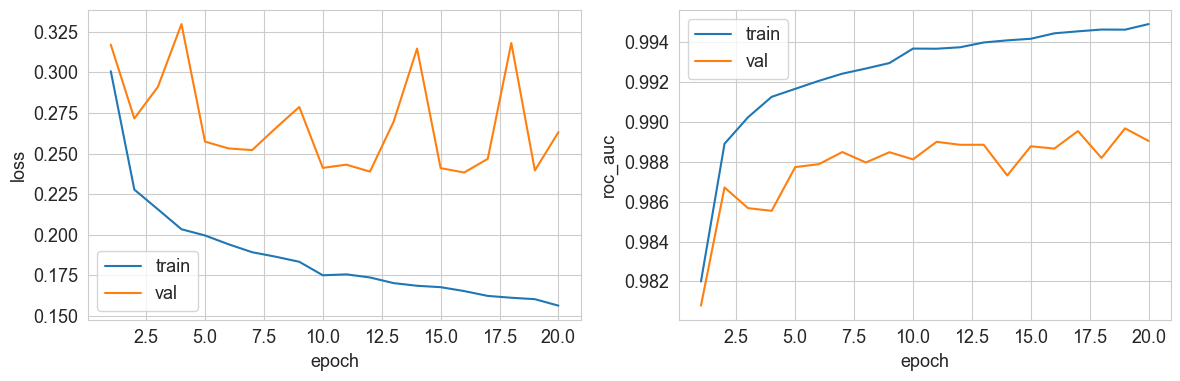

Epoch 20: train_loss=0.1563 val_loss=0.2632 train_auc=0.9949 val_auc=0.9890
Средний NDCG: 0.7465
Средний Precision: 0.6660
Средний Recall: 0.7058
Средний F1-Score: 0.6729
🏃 View run MLP_d4_h512_256_128_64 at: http://127.0.0.1:5000/#/experiments/1/runs/eae1d21a4b484a4a999659a8c0e8838a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [78]:
input_dim = X_train_tab.shape[1]

mlp_configs = [
    {'name': 'MLP_d1_h128',          'hidden_sizes': [128],                'dropout': 0.0, 'use_bn': False},
    {'name': 'MLP_d2_h128_64_dr02',  'hidden_sizes': [128, 64],            'dropout': 0.2, 'use_bn': False},
    {'name': 'MLP_d3_h256_128_64_bn','hidden_sizes': [256, 128, 64],       'dropout': 0.3, 'use_bn': True},
    {'name': 'MLP_d4_h512_256_128_64','hidden_sizes': [512, 256, 128, 64], 'dropout': 0.3, 'use_bn': True},
]

mlp_results = {}
for cfg in mlp_configs:
    print(f"\n=== {cfg['name']} ===")
    torch.manual_seed(RANDOM_STATE)
    model = TabularMLP(
        input_dim=input_dim,
        hidden_sizes=cfg['hidden_sizes'],
        dropout=cfg['dropout'],
        use_bn=cfg['use_bn'],
    )
    metrics, _ = run_dl_experiment(
        run_name=cfg['name'],
        model=model,
        train_loader=train_tab_loader,
        test_loader=test_tab_loader,
        forward_fn=tab_forward,
        num_epochs=20,
        lr=1e-3,
        weight_decay=1e-5,
        hyperparams={'hidden_sizes': str(cfg['hidden_sizes']),
                     'dropout': cfg['dropout'],
                     'use_bn': cfg['use_bn']},
    )
    mlp_results[cfg['name']] = metrics

In [79]:
mlp_summary = pd.DataFrame(mlp_results).T[['NDCG', 'Precision', 'Recall', 'F1', 'val_auc_last']]
mlp_summary

,NDCG,Precision,Recall,F1,val_auc_last
MLP_d1_h128,0.740659,0.642118,0.693977,0.652088,0.983345
MLP_d2_h128_64_dr02,0.744446,0.656847,0.707040,0.667640,0.987565
MLP_d3_h256_128_64_bn,0.746178,0.632503,0.719923,0.657638,0.989513
MLP_d4_h512_256_128_64,0.746522,0.665978,0.705793,0.672893,0.989032


## TextClassifier

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Берём тексты vacancy_description + SEP + resume_last_experience_description
- Токенизация - BPE через sentencepiece

</div>

In [80]:
import os
from sentencepiece import SentencePieceTrainer, SentencePieceProcessor

df['_text_for_dl'] = (
    df['vacancy_description'].fillna('').astype(str)
    + ' [SEP] '
    + df['resume_last_experience_description'].fillna('').astype(str)
)

CORPUS_FILE = 'dl_text_corpus.txt'
SP_PREFIX = 'dl_bpe'
VOCAB_SIZE = 4000

if not os.path.isfile(CORPUS_FILE):
    with open(CORPUS_FILE, 'w', encoding='utf-8') as f:
        for t in df['_text_for_dl'].tolist():
            f.write(t.replace('\n', ' ') + '\n')

if not os.path.isfile(SP_PREFIX + '.model'):
    SentencePieceTrainer.train(
        input=CORPUS_FILE,
        vocab_size=VOCAB_SIZE,
        model_type='bpe',
        model_prefix=SP_PREFIX,
        normalization_rule_name='identity',
        character_coverage=1.0,
    )

sp_model = SentencePieceProcessor(model_file=SP_PREFIX + '.model')

In [81]:
class ResumeVacancyTextDataset(Dataset):

    def __init__(self, texts, targets, sp_model, max_length=128):
        self.sp_model = sp_model
        self.max_length = max_length
        self.indices = self.sp_model.encode(list(texts))
        self.targets = np.asarray(targets, dtype=np.float32)
        self.pad_id = self.sp_model.pad_id()
        self.bos_id = self.sp_model.bos_id()
        self.eos_id = self.sp_model.eos_id()
        self.vocab_size = self.sp_model.vocab_size()
        if self.pad_id < 0:
            self.pad_id = 0

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        enc = [self.bos_id] + self.indices[item] + [self.eos_id]
        length = min(len(enc), self.max_length)
        enc = enc[:self.max_length]
        pad_len = self.max_length - len(enc)
        enc = enc + [self.pad_id] * pad_len
        indices = torch.tensor(enc, dtype=torch.long)
        return indices, length, torch.tensor(self.targets[item], dtype=torch.float32)


train_text_dataset = ResumeVacancyTextDataset(
    df.loc[X_train.index, '_text_for_dl'].tolist(),
    y_train.values,
    sp_model,
    max_length=128,
)
test_text_dataset = ResumeVacancyTextDataset(
    df.loc[X_test.index, '_text_for_dl'].tolist(),
    y_test.values,
    sp_model,
    max_length=128,
)

train_text_loader = DataLoader(train_text_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_text_loader = DataLoader(test_text_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [82]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=128,
                 rnn_type=nn.RNN, rnn_layers=1, dropout=0.0, pad_id=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_id)
        self.rnn = rnn_type(embed_size, hidden_size,
                            num_layers=rnn_layers, batch_first=True,
                            dropout=dropout if rnn_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, indices, lengths):
        max_len = lengths.max().item()
        indices = indices[:, :max_len]

        emb = self.embedding(indices)
        out, _ = self.rnn(emb)

        idx = (lengths - 1).clamp(min=0).to(out.device)
        last_hidden = out[torch.arange(out.size(0), device=out.device), idx]
        last_hidden = self.dropout(last_hidden)
        logits = self.linear(last_hidden)
        return logits


def text_forward(model, batch):
    indices, lengths, y = batch
    indices = indices.to(device)
    lengths = lengths.to(device)
    y = y.to(device)
    logits = model(indices, lengths).squeeze(-1)
    return logits, y

### RNN

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сначала обучим обычную RNN

</div>

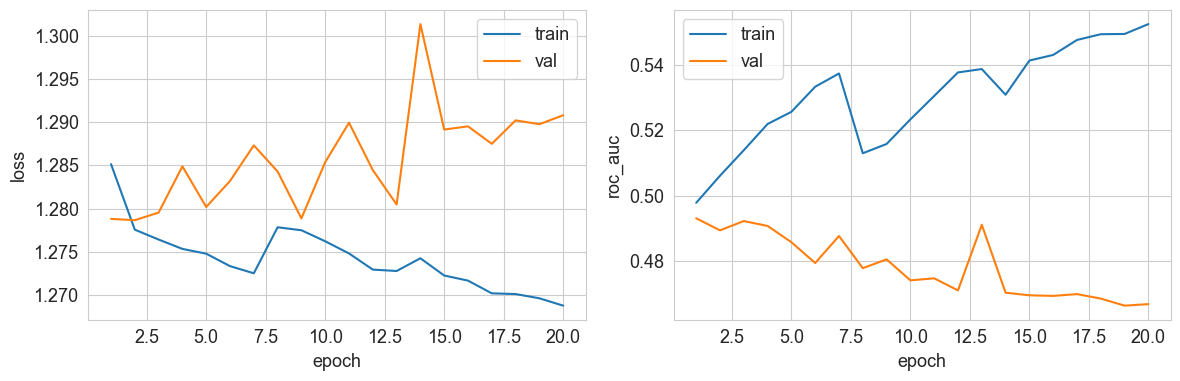

Epoch 20: train_loss=1.2687 val_loss=1.2908 train_auc=0.5525 val_auc=0.4668
Средний NDCG: 0.3292
Средний Precision: 0.0334
Средний Recall: 0.3452
Средний F1-Score: 0.0598
🏃 View run RNN_text at: http://127.0.0.1:5000/#/experiments/1/runs/7e4adfdfd5a44dafb1548859c11e8c00
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [83]:
torch.manual_seed(RANDOM_STATE)
rnn_model = TextClassifier(
    vocab_size=sp_model.vocab_size(),
    embed_size=128,
    hidden_size=128,
    rnn_type=nn.RNN,
    rnn_layers=1,
    dropout=0.2,
    pad_id=train_text_dataset.pad_id,
)

metrics_rnn, _ = run_dl_experiment(
    run_name='RNN_text',
    model=rnn_model,
    train_loader=train_text_loader,
    test_loader=test_text_loader,
    forward_fn=text_forward,
    num_epochs=20,
    lr=1e-3,
    weight_decay=1e-5,
    hyperparams={'embed_size': 128, 'hidden_size': 128, 'rnn_type': 'RNN',
                 'rnn_layers': 1, 'dropout': 0.2, 'max_length': 128, 'vocab_size': VOCAB_SIZE},
)

### LSTM

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Теперь LSTM

</div>

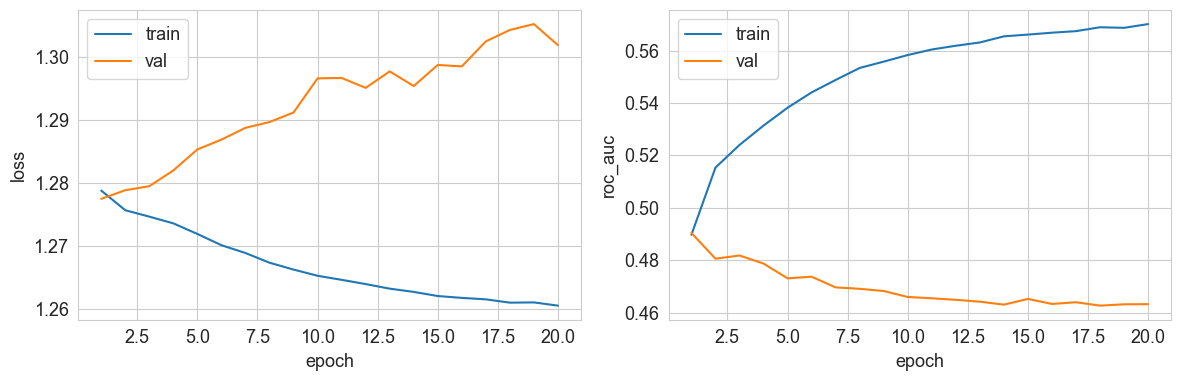

Epoch 20: train_loss=1.2606 val_loss=1.3020 train_auc=0.5701 val_auc=0.4633
Средний NDCG: 0.3295
Средний Precision: 0.0447
Средний Recall: 0.4513
Средний F1-Score: 0.0798
🏃 View run LSTM_text at: http://127.0.0.1:5000/#/experiments/1/runs/1eb731447b6e418485deda07f9884afe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [84]:
torch.manual_seed(RANDOM_STATE)
lstm_model = TextClassifier(
    vocab_size=sp_model.vocab_size(),
    embed_size=128,
    hidden_size=128,
    rnn_type=nn.LSTM,
    rnn_layers=1,
    dropout=0.2,
    pad_id=train_text_dataset.pad_id,
)

metrics_lstm, _ = run_dl_experiment(
    run_name='LSTM_text',
    model=lstm_model,
    train_loader=train_text_loader,
    test_loader=test_text_loader,
    forward_fn=text_forward,
    num_epochs=20,
    lr=1e-3,
    weight_decay=1e-5,
    hyperparams={'embed_size': 128, 'hidden_size': 128, 'rnn_type': 'LSTM',
                 'rnn_layers': 1, 'dropout': 0.2, 'max_length': 128, 'vocab_size': VOCAB_SIZE},
)

## HybridMLPLSTM — гибрид табличной и текстовой ветки

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Соберём модель, которая использует все опробованные признаки одновременно:

- Текстовая ветка: Embedding - LSTM - последний скрытый как в TextClassifier
- Табличная ветка: Linear - ReLU
- Ветки конкатенируются и проходят через общую голову Linear - ReLU - Linear

</div>

In [85]:
class HybridDataset(Dataset):
    def __init__(self, text_dataset, tabular_features):
        assert len(text_dataset) == len(tabular_features)
        self.text_dataset = text_dataset
        self.tab = tabular_features.astype(np.float32)

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, item):
        indices, length, target = self.text_dataset[item]
        return indices, length, torch.from_numpy(self.tab[item]), target


train_hybrid_dataset = HybridDataset(train_text_dataset, X_train_tab)
test_hybrid_dataset = HybridDataset(test_text_dataset, X_test_tab)

train_hybrid_loader = DataLoader(train_hybrid_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_hybrid_loader = DataLoader(test_hybrid_dataset, batch_size=BATCH_SIZE, shuffle=False)


def hybrid_forward(model, batch):
    indices, lengths, tab, y = batch
    indices = indices.to(device)
    lengths = lengths.to(device)
    tab = tab.to(device)
    y = y.to(device)
    logits = model(indices, lengths, tab).squeeze(-1)
    return logits, y

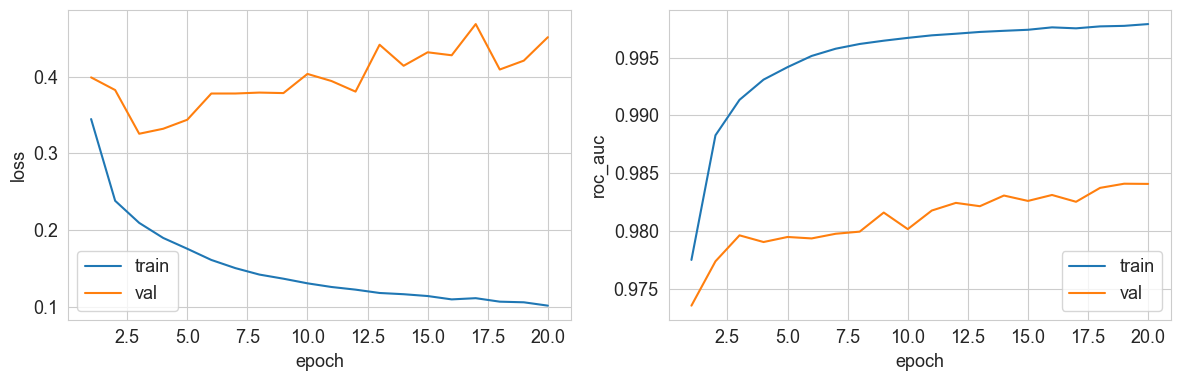

Epoch 20: train_loss=0.1015 val_loss=0.4515 train_auc=0.9979 val_auc=0.9841
Средний NDCG: 0.7429
Средний Precision: 0.6493
Средний Recall: 0.7058
Средний F1-Score: 0.6612
🏃 View run Hybrid_LSTM_MLP at: http://127.0.0.1:5000/#/experiments/1/runs/00af29453a574c0789e21572b1dbd740
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [86]:
class HybridMLPLSTM(nn.Module):
    def __init__(self, vocab_size, tab_dim, embed_size=128, hidden_size=128,
                 rnn_type=nn.LSTM, rnn_layers=1, tab_hidden=64,
                 head_hidden=64, dropout=0.2, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_id)
        self.rnn = rnn_type(embed_size, hidden_size,
                            num_layers=rnn_layers, batch_first=True,
                            dropout=dropout if rnn_layers > 1 else 0.0)

        self.tab_branch = nn.Sequential(
            nn.Linear(tab_dim, tab_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size + tab_hidden, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )

    def forward(self, indices, lengths, tab):
        max_len = lengths.max().item()
        indices = indices[:, :max_len]
        emb = self.embedding(indices)
        out, _ = self.rnn(emb)
        idx = (lengths - 1).clamp(min=0).to(out.device)
        text_repr = out[torch.arange(out.size(0), device=out.device), idx]

        tab_repr = self.tab_branch(tab)
        joint = torch.cat([text_repr, tab_repr], dim=-1)
        return self.head(joint)


torch.manual_seed(RANDOM_STATE)
hybrid_model = HybridMLPLSTM(
    vocab_size=sp_model.vocab_size(),
    tab_dim=X_train_tab.shape[1],
    embed_size=128,
    hidden_size=128,
    rnn_type=nn.LSTM,
    rnn_layers=1,
    tab_hidden=64,
    head_hidden=64,
    dropout=0.3,
    pad_id=train_text_dataset.pad_id,
)

metrics_hybrid, _ = run_dl_experiment(
    run_name='Hybrid_LSTM_MLP',
    model=hybrid_model,
    train_loader=train_hybrid_loader,
    test_loader=test_hybrid_loader,
    forward_fn=hybrid_forward,
    num_epochs=20,
    lr=1e-3,
    weight_decay=1e-5,
    hyperparams={'embed_size': 128, 'hidden_size': 128, 'rnn_type': 'LSTM',
                 'tab_hidden': 64, 'head_hidden': 64, 'dropout': 0.3,
                 'tab_dim': X_train_tab.shape[1]},
)

## Подбор гиперпараметров

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Подберем гиперпараметры (hidden_size, tab_hidden, head_hidden, dropout, lr, weight_decay)

</div>

In [87]:
def objective_hybrid(trial: optuna.Trial) -> float:
    hidden_size = trial.suggest_categorical('hidden_size', [64, 128, 256])
    tab_hidden = trial.suggest_categorical('tab_hidden', [32, 64, 128])
    head_hidden = trial.suggest_categorical('head_hidden', [32, 64, 128])
    dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.1)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    torch.manual_seed(RANDOM_STATE)
    model = HybridMLPLSTM(
        vocab_size=sp_model.vocab_size(),
        tab_dim=X_train_tab.shape[1],
        embed_size=128,
        hidden_size=hidden_size,
        rnn_type=nn.LSTM,
        rnn_layers=1,
        tab_hidden=tab_hidden,
        head_hidden=head_hidden,
        dropout=dropout,
        pad_id=train_text_dataset.pad_id,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_model(model, optimizer, criterion, train_hybrid_loader, test_hybrid_loader,
                num_epochs=20, forward_fn=hybrid_forward, verbose=False)

    y_pred_proba_test = predict_proba(model, test_hybrid_loader, hybrid_forward)
    df_test_dl = df.loc[X_test.index].copy()
    df_test_dl['y_pred_proba'] = y_pred_proba_test
    ndcg, _, _, _ = calculate_metrics(df_test_dl)

    trial.set_user_attr('hidden_size', hidden_size)
    trial.set_user_attr('tab_hidden', tab_hidden)
    trial.set_user_attr('head_hidden', head_hidden)
    trial.set_user_attr('dropout', dropout)
    trial.set_user_attr('lr', lr)
    trial.set_user_attr('weight_decay', weight_decay)

    return ndcg

In [88]:
try:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
except Exception:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

RUN_NAME_OPTUNE_HYBRID = 'HybridMLPLSTM_optuna'

with mlflow.start_run(run_name=RUN_NAME_OPTUNE_HYBRID, experiment_id=experiment_id) as run:
    run_id_hybrid = run.info.run_id

STUDY_DB_NAME = "sqlite:///local.study.db"
STUDY_NAME_HYBRID = "HybridMLPLSTM_optuna"

mlflc_hybrid = MLflowCallback(
    tracking_uri=f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}',
    metric_name="NDCG",
    create_experiment=False,
    mlflow_kwargs={'experiment_id': experiment_id, 'tags': {MLFLOW_PARENT_RUN_ID: run_id_hybrid}}
)

study_hybrid = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name=STUDY_NAME_HYBRID,
    storage=STUDY_DB_NAME,
    load_if_exists=True,
)
study_hybrid.optimize(objective_hybrid, n_trials=8, callbacks=[mlflc_hybrid])

best_params_hybrid = study_hybrid.best_params

[I 2026-05-03 01:32:23,603] Using an existing study with name 'HybridMLPLSTM_optuna' instead of creating a new one.


🏃 View run HybridMLPLSTM_optuna at: http://127.0.0.1:5000/#/experiments/1/runs/9eca9494a1e14ae495085199a3822c82
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:35:21,787] Trial 16 finished with value: 0.742404813246072 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 128, 'dropout': 0.2, 'lr': 0.0009140283686703725, 'weight_decay': 3.7517528827511507e-06}. Best is trial 16 with value: 0.742404813246072.


Средний NDCG: 0.7424
Средний Precision: 0.6545
Средний Recall: 0.6915
Средний F1-Score: 0.6581
🏃 View run 16 at: http://127.0.0.1:5000/#/experiments/1/runs/0b07398a89bb44c989f56b84ecfc9fd7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:38:19,831] Trial 17 finished with value: 0.7393738308153912 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 32, 'dropout': 0.2, 'lr': 0.000726041530983983, 'weight_decay': 4.199525075325586e-06}. Best is trial 16 with value: 0.742404813246072.


Средний NDCG: 0.7394
Средний Precision: 0.6377
Средний Recall: 0.6914
Средний F1-Score: 0.6472
🏃 View run 17 at: http://127.0.0.1:5000/#/experiments/1/runs/99ad895c99064e4f933fac3ba3c81d67
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:41:19,434] Trial 18 finished with value: 0.7424727910591182 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 128, 'dropout': 0.2, 'lr': 0.0009854467883139008, 'weight_decay': 4.040146294737043e-06}. Best is trial 18 with value: 0.7424727910591182.


Средний NDCG: 0.7425
Средний Precision: 0.6598
Средний Recall: 0.6950
Средний F1-Score: 0.6636
🏃 View run 18 at: http://127.0.0.1:5000/#/experiments/1/runs/9f8564300d224818ab94a8d2c146ae87
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:44:17,748] Trial 19 finished with value: 0.7431745546900258 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 128, 'dropout': 0.2, 'lr': 0.000908134111491514, 'weight_decay': 7.100856903448834e-06}. Best is trial 19 with value: 0.7431745546900258.


Средний NDCG: 0.7432
Средний Precision: 0.6524
Средний Recall: 0.6998
Средний F1-Score: 0.6613
🏃 View run 19 at: http://127.0.0.1:5000/#/experiments/1/runs/4a84edbe0a3346009b75c1b1dfe18ac5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:47:16,113] Trial 20 finished with value: 0.7424427307838557 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 32, 'dropout': 0.1, 'lr': 0.0012766043558568804, 'weight_decay': 7.792725936217e-06}. Best is trial 19 with value: 0.7431745546900258.


Средний NDCG: 0.7424
Средний Precision: 0.6467
Средний Recall: 0.6994
Средний F1-Score: 0.6568
🏃 View run 20 at: http://127.0.0.1:5000/#/experiments/1/runs/91b90ebbcfde454ead7d9166480fa264
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:50:14,392] Trial 21 finished with value: 0.7410667696474239 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 32, 'dropout': 0.1, 'lr': 0.00109117357316553, 'weight_decay': 7.678007902760838e-06}. Best is trial 19 with value: 0.7431745546900258.


Средний NDCG: 0.7411
Средний Precision: 0.6492
Средний Recall: 0.6904
Средний F1-Score: 0.6545
🏃 View run 21 at: http://127.0.0.1:5000/#/experiments/1/runs/3a4638c2b4d24e5393e189c4b7556ed7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:53:12,693] Trial 22 finished with value: 0.7395653260244239 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 32, 'dropout': 0.1, 'lr': 0.000503939214554063, 'weight_decay': 2.2055284500449354e-05}. Best is trial 19 with value: 0.7431745546900258.


Средний NDCG: 0.7396
Средний Precision: 0.6359
Средний Recall: 0.6871
Средний F1-Score: 0.6439
🏃 View run 22 at: http://127.0.0.1:5000/#/experiments/1/runs/f26efeef7f9d4b3dbafa8dccfc3d9fde
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Train 1/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   1/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 2/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   2/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 3/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   3/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 4/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   4/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 5/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   5/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 6/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   6/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 7/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   7/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 8/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   8/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 9/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   9/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 10/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   10/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 11/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   11/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 12/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   12/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 13/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   13/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 14/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   14/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 15/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   15/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 16/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   16/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 17/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   17/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 18/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   18/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 19/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   19/20:   0%|          | 0/117 [00:00<?, ?it/s]

Train 20/20:   0%|          | 0/465 [00:00<?, ?it/s]

Val   20/20:   0%|          | 0/117 [00:00<?, ?it/s]

[I 2026-05-03 01:56:11,429] Trial 23 finished with value: 0.7426293005714186 and parameters: {'hidden_size': 64, 'tab_hidden': 32, 'head_hidden': 32, 'dropout': 0.2, 'lr': 0.0013314588368132704, 'weight_decay': 7.441882749844193e-06}. Best is trial 19 with value: 0.7431745546900258.


Средний NDCG: 0.7426
Средний Precision: 0.6459
Средний Recall: 0.7049
Средний F1-Score: 0.6589
🏃 View run 23 at: http://127.0.0.1:5000/#/experiments/1/runs/60b0ab15cdfc4ce7a1b83e5b57058841
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


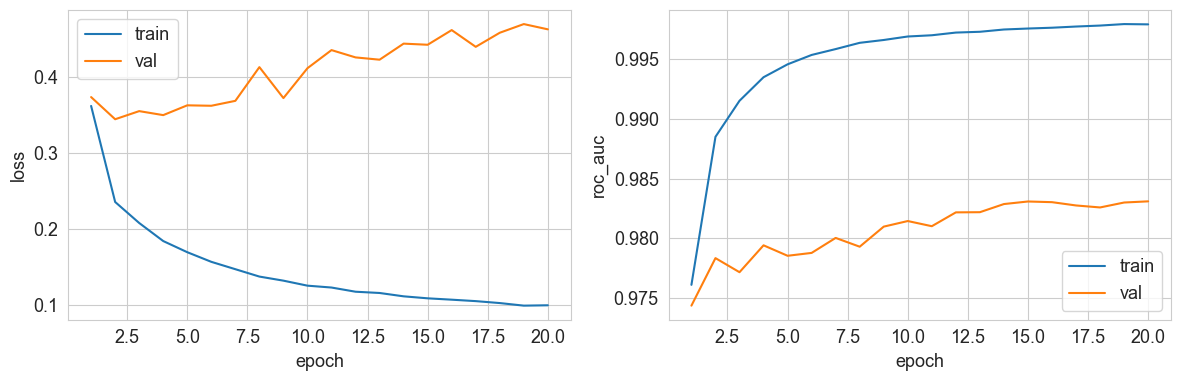

Epoch 20: train_loss=0.1002 val_loss=0.4620 train_auc=0.9979 val_auc=0.9831
Средний NDCG: 0.7432
Средний Precision: 0.6524
Средний Recall: 0.6998
Средний F1-Score: 0.6613
🏃 View run best_optuna_hybrid at: http://127.0.0.1:5000/#/experiments/1/runs/b9e422015e1848a8a0040fc0adb3aaf5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [89]:
torch.manual_seed(RANDOM_STATE)
best_hybrid_model = HybridMLPLSTM(
    vocab_size=sp_model.vocab_size(),
    tab_dim=X_train_tab.shape[1],
    embed_size=128,
    hidden_size=best_params_hybrid['hidden_size'],
    rnn_type=nn.LSTM,
    rnn_layers=1,
    tab_hidden=best_params_hybrid['tab_hidden'],
    head_hidden=best_params_hybrid['head_hidden'],
    dropout=best_params_hybrid['dropout'],
    pad_id=train_text_dataset.pad_id,
)

metrics_hybrid_best, best_hybrid_model = run_dl_experiment(
    run_name='best_optuna_hybrid',
    model=best_hybrid_model,
    train_loader=train_hybrid_loader,
    test_loader=test_hybrid_loader,
    forward_fn=hybrid_forward,
    num_epochs=20,
    lr=best_params_hybrid['lr'],
    weight_decay=best_params_hybrid['weight_decay'],
    hyperparams=best_params_hybrid,
)

## Сравним модели

In [90]:
rows = [
    ('LogisticRegression',     ndcg_lr,             precision_lr,             recall_lr,             f1_lr),
    ('CatBoost + ALS',         ndcg_catboost_als,   precision_catboost_als,   recall_catboost_als,   f1_catboost_als),
]
for name, m in mlp_results.items():
    rows.append((name, m['NDCG'], m['Precision'], m['Recall'], m['F1']))
rows += [
    ('RNN_text',               metrics_rnn['NDCG'],         metrics_rnn['Precision'],         metrics_rnn['Recall'],         metrics_rnn['F1']),
    ('LSTM_text',              metrics_lstm['NDCG'],        metrics_lstm['Precision'],        metrics_lstm['Recall'],        metrics_lstm['F1']),
    ('Hybrid_LSTM_MLP',        metrics_hybrid['NDCG'],      metrics_hybrid['Precision'],      metrics_hybrid['Recall'],      metrics_hybrid['F1']),
    ('Hybrid_LSTM_MLP_optuna', metrics_hybrid_best['NDCG'], metrics_hybrid_best['Precision'], metrics_hybrid_best['Recall'], metrics_hybrid_best['F1']),
]

models_comparison = pd.DataFrame(rows, columns=['Model', 'NDCG', 'Precision', 'Recall', 'F1'])
models_comparison = models_comparison.sort_values('NDCG', ascending=False).reset_index(drop=True)
models_comparison

,Model,NDCG,Precision,Recall,F1
0,CatBoost + ALS,0.747989,0.641142,0.731079,0.668372
1,MLP_d4_h512_256_128_64,0.746522,0.665978,0.705793,0.672893
2,MLP_d3_h256_128_64_bn,0.746178,0.632503,0.719923,0.657638
3,MLP_d2_h128_64_dr02,0.744446,0.656847,0.707040,0.667640
4,Hybrid_LSTM_MLP_optuna,0.743175,0.652360,0.699814,0.661283
5,Hybrid_LSTM_MLP,0.742859,0.649302,0.705793,0.661160
6,MLP_d1_h128,0.740659,0.642118,0.693977,0.652088
7,LogisticRegression,0.720894,0.607475,0.565420,0.569929
8,LSTM_text,0.329473,0.044699,0.451281,0.079814
9,RNN_text,0.329197,0.033420,0.345214,0.059809


In [91]:
best_model_idx = models_comparison['NDCG'].idxmax()
print(f"\nЛучшая модель: {models_comparison.iloc[best_model_idx]['Model']} с NDCG = {models_comparison.iloc[best_model_idx]['NDCG']:.4f}")


Лучшая модель: CatBoost + ALS с NDCG = 0.7480


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сохраним обученный итоговый CatBoost-пайплайн (бейзлайн) и лучшую DL-модель

</div>

In [92]:
with open('pipeline_catboost_best.pkl', 'wb') as file:
    pickle.dump(pipeline_catboost_best, file)

torch.save(best_hybrid_model.state_dict(), 'best_hybrid_dl_model.pt')